In [79]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os


In [136]:
visited = pd.DataFrame()

In [137]:
def read_memory(path: str):
    df = pd.read_csv(path, header=None)
    df.drop(df.columns[-1], axis=1, inplace=True)
    return df

In [138]:
def get_file_list():
    file_list = []
    for file in os.listdir('/home/timok/CLionProjects/PSOMAB/cmake-build-debug/'):  #Add path
        if file.startswith('ackley_psomab_memory'):
            file_list.append(file)
    return file_list

In [139]:
def aggregate_memory(files):
    df = pd.DataFrame()
    for file in files:
        path = '/home/timok/CLionProjects/PSOMAB/cmake-build-debug/' + file  #Add path
        df_temp = read_memory(path)
        df = df.add(df_temp, fill_value=0)
    df = df / len(files)
    return df

In [140]:
visited = aggregate_memory(get_file_list())

In [141]:
# logaritm
visited = visited.apply(lambda x: np.log10(x))

/home/timok/anaconda3/envs/PSOMAB/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: title={'center': 'Visited Solutions'}>

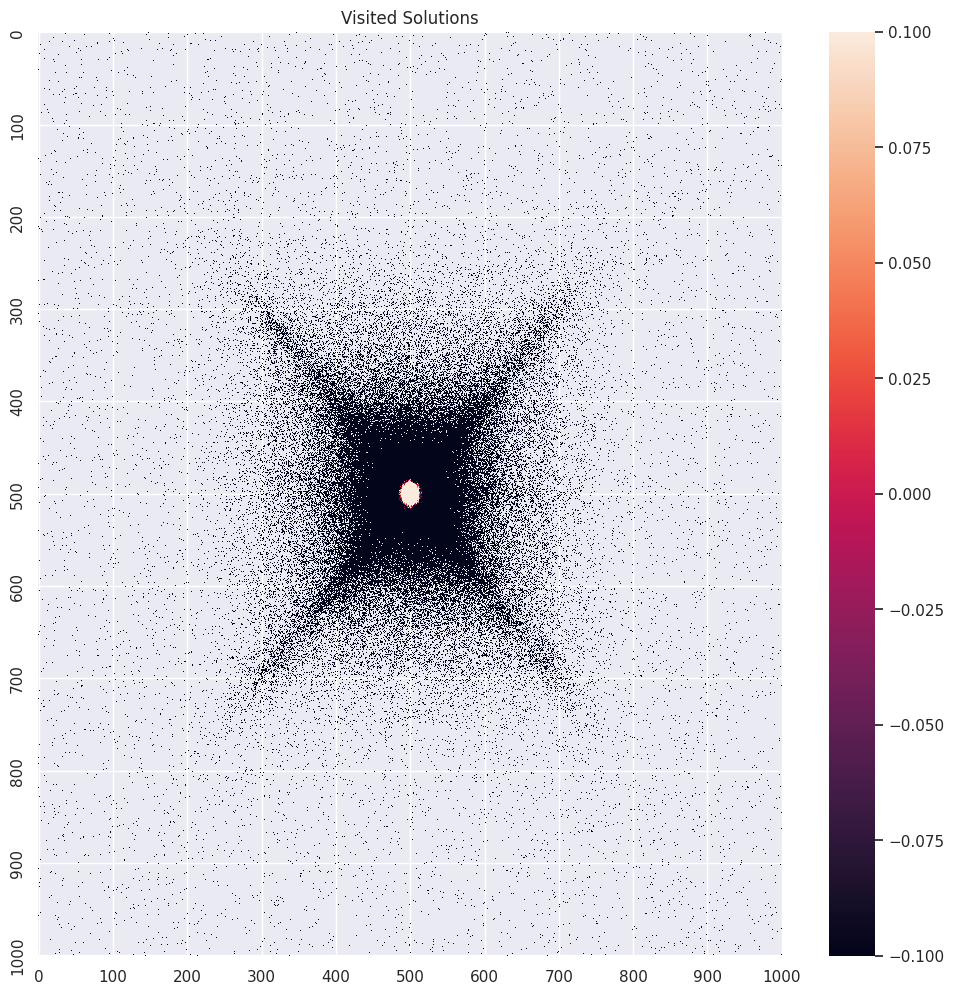

In [142]:
sns.set(rc = {'figure.figsize':(12,12)})
fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_title('Visited Solutions')
ax.set_ylabel('y')
sns.heatmap(visited, xticklabels=100, yticklabels=100, ax=ax)

In [49]:
optimality_gaps = pd.DataFrame()

In [50]:
def read_csv(path: str, save_after: int):
    df = pd.read_csv(path, header=None)
    df.drop(df.columns[-1], axis=1, inplace=True)
    df = df.T
    df = df.reindex(df.index.repeat(save_after)).reset_index(drop=True)
    return df

In [51]:
def get_optimality_gap(df: pd.DataFrame, optimum: float):
    return df.sum(axis=1)/df.shape[1] - optimum

In [52]:
psomab_ackley_df = read_csv('/home/timok/CLionProjects/PSOMAB/cmake-build-debug/ackley_psomab_1682411200.csv', 10)
optimality_gaps['psomab'] = get_optimality_gap(psomab_ackley_df, 0)

In [53]:
psoan_ackley_df = read_csv('/home/timok/CLionProjects/PSOMAB/cmake-build-debug/ackley_psoan_1682412144.csv', 10)
optimality_gaps['psoan'] = get_optimality_gap(psoan_ackley_df, 0)

In [54]:
lapso_ackley_df = read_csv('/home/timok/CLionProjects/PSOMAB/cmake-build-debug/ackley_lapso_1682412052.csv', 10)
optimality_gaps['lapso'] = get_optimality_gap(lapso_ackley_df, 0)

In [55]:
ocbaa_ackley_df = read_csv('/home/timok/CLionProjects/PSOMAB/cmake-build-debug/ackley_psoocbaa_1682411989.csv', 10)
optimality_gaps['ocbaa'] = get_optimality_gap(ocbaa_ackley_df, 0)

In [56]:
pso_ackley_df = read_csv('/home/timok/CLionProjects/PSOMAB/cmake-build-debug/ackley_pso_1682411965.csv', 10)
optimality_gaps['pso'] = get_optimality_gap(pso_ackley_df, 0)

In [57]:
psogd_ackley_df = read_csv('/home/timok/CLionProjects/PSOMAB/cmake-build-debug/ackley_psogd_1682411962.csv', 10)
optimality_gaps['psogd'] = get_optimality_gap(psogd_ackley_df, 0)

In [58]:
psoern_ackley_df = read_csv('/home/timok/CLionProjects/PSOMAB/cmake-build-debug/ackley_psoern_1682411935.csv', 10)
optimality_gaps['psoern'] = get_optimality_gap(psoern_ackley_df, 0)

<Axes: title={'center': 'Optimality gap of Algorithms on the Ackley function'}, xlabel='Evaluations of the objective function', ylabel='Optimality gap'>

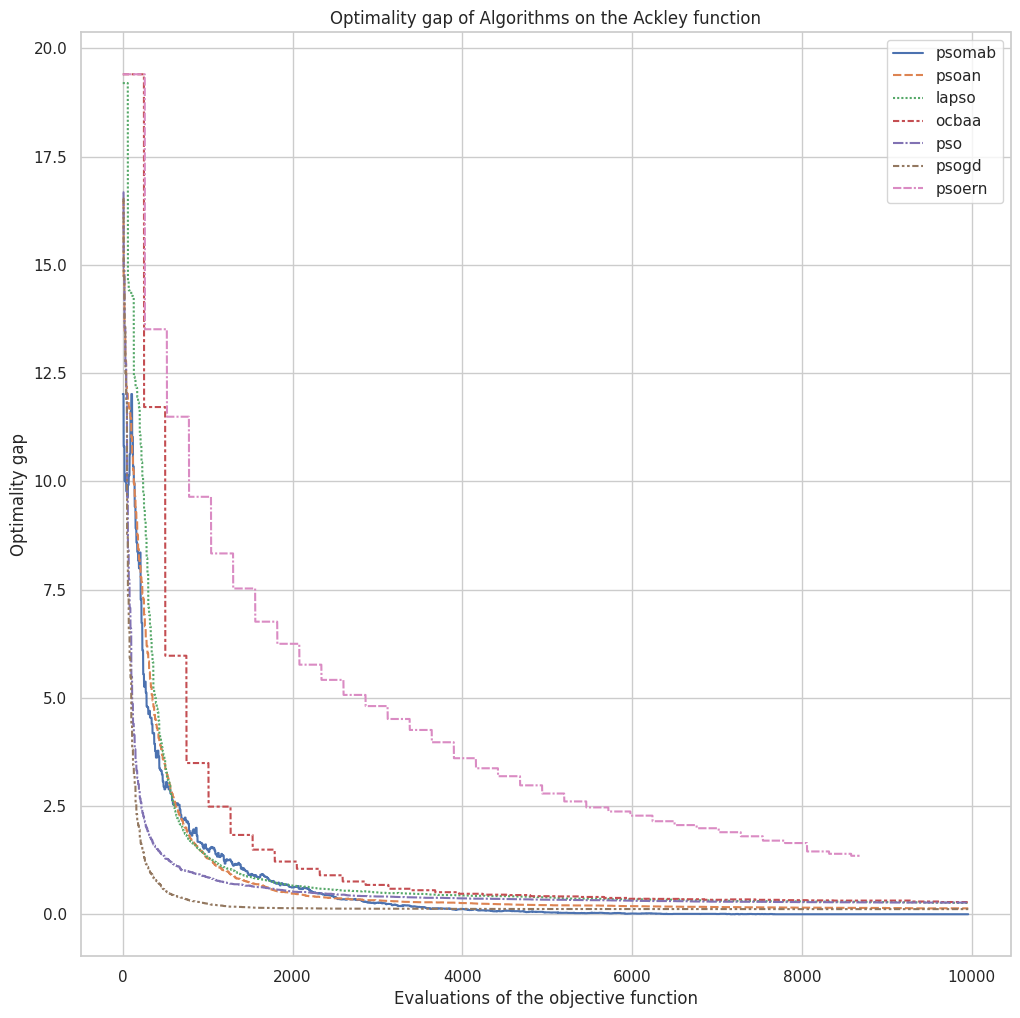

In [59]:
sns.set(rc = {'figure.figsize':(12,12)})
sns.set_style('whitegrid')
fig, ax = plt.subplots()
ax.set_xlabel('Evaluations of the objective function')
ax.set_title('Optimality gap of Algorithms on the Ackley function')
ax.set_ylabel('Optimality gap')
sns.lineplot(data=optimality_gaps, ax=ax)

In [60]:
best_values = pd.DataFrame()

In [66]:
def get_best_values(df: pd.DataFrame, optimum: float):
    return df.iloc[-1] - optimum

In [69]:
best_values['psomab'] = get_best_values(psomab_ackley_df, 0)
best_values['psoan'] = get_best_values(psoan_ackley_df, 0)
best_values['lapso'] = get_best_values(lapso_ackley_df, 0)
best_values['ocbaa'] = get_best_values(ocbaa_ackley_df, 0)
best_values['pso'] = get_best_values(pso_ackley_df, 0)
best_values['psogd'] = get_best_values(psogd_ackley_df, 0)
best_values['psoern'] = get_best_values(psoern_ackley_df, 0)

<Axes: title={'center': 'Optimality gap of Algorithms on the Ackley function'}, xlabel='Algorithms', ylabel='Optimality gap'>

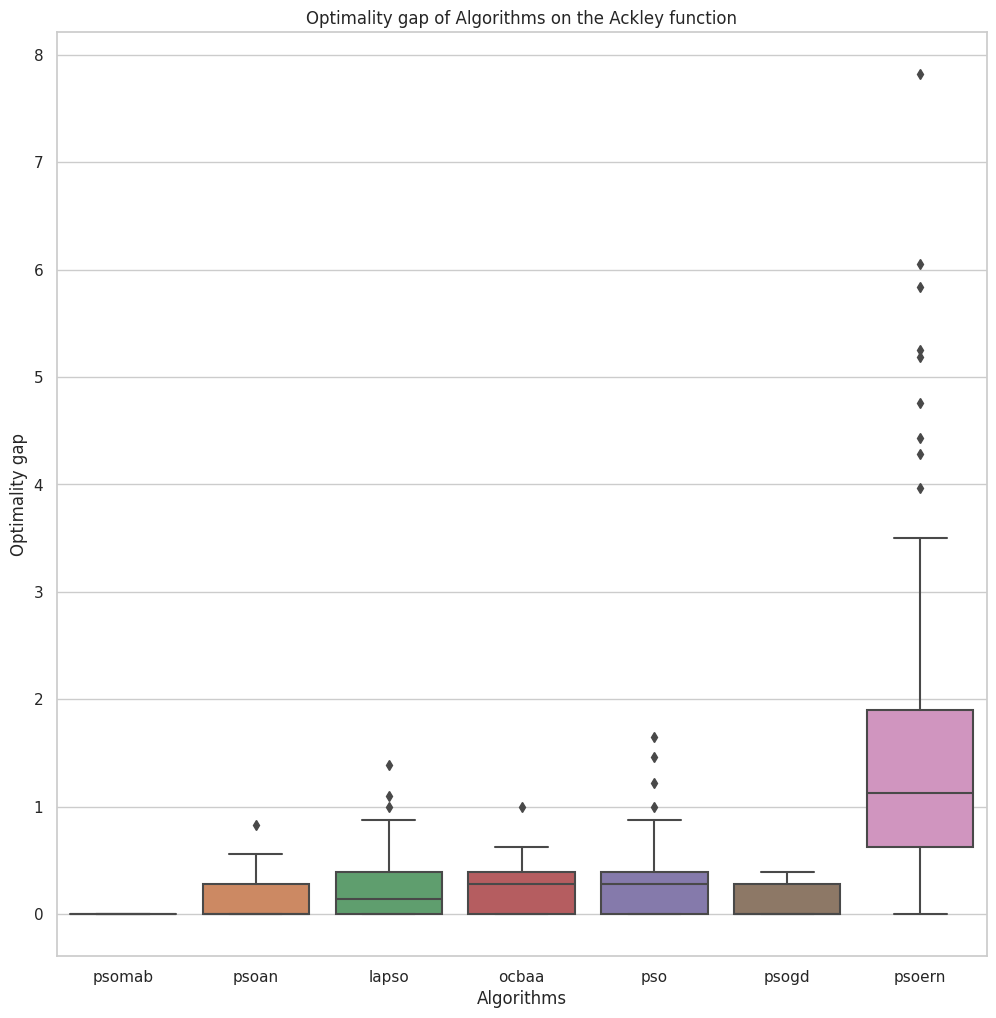

In [70]:
sns.set(rc = {'figure.figsize':(12,12)})
sns.set_style('whitegrid')
fig, ax = plt.subplots()
ax.set_xlabel('Algorithms')
ax.set_title('Optimality gap of Algorithms on the Ackley function')
ax.set_ylabel('Optimality gap')
sns.boxplot(data=best_values, ax=ax)